In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
lchs_data = np.load("lchs_tfim_data.npz")
t_vals = lchs_data["t_vals"]
obs_gt = lchs_data["obs_gt"]
lchs_obs_sim = lchs_data["observable_sim_simuq"] 
lchs_std_error_sim = lchs_data["std_error_sim_simuq"]
lchs_observable_qpu = lchs_data["observable_qpu_simuq"]
lchs_std_error_qpu = lchs_data["std_error_qpu_simuq"]

schrodingerization_data = np.load("schrodingerization_tfim_data.npz")
schro_obs_sim = schrodingerization_data["obs_sim_simuq"]
schro_std_error_sim = schrodingerization_data["std_error_sim_simuq"]
schro_qpu = schrodingerization_data["obs_qpu_simuq"]
schro_std_error_qpu = schrodingerization_data["std_error_qpu_simuq"]

lchs_color = '#1f77b4'  # Hex code for blue
schr_color = '#d62728'  # Hex code for red

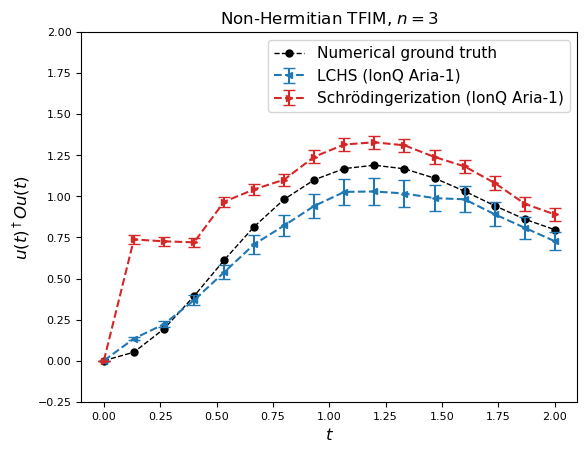

In [43]:
plt.figure()
plt.plot(t_vals, obs_gt, '--o', markersize=5, color="black", label="Numerical ground truth", linewidth=1)
plt.errorbar(t_vals, lchs_observable_qpu, lchs_std_error_qpu, fmt='--<', markersize=5, color=lchs_color, label="LCHS (IonQ Aria-1)", capsize=4)
plt.errorbar(t_vals, schro_qpu, schro_std_error_qpu, fmt='-->', markersize=5, color=schr_color, label="Schrödingerization (IonQ Aria-1)", capsize=4)
plt.ylabel(r"$u(t)^\dagger O u(t)$", fontsize=12)
plt.xlabel(r"$t$", fontsize=12)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend(fontsize=11)
plt.ylim(-0.25, 2)
plt.title(f"Non-Hermitian TFIM, $n=3$")
plt.savefig('tfim_fig.png', dpi=300, bbox_inches='tight')

Resource analysis

In [ ]:
lchs_data = np.load("../data/1d_tfim/lchs.npz")
N_vals_binary = lchs_data["N_vals_binary"]
binary_trotter_steps = lchs_data["binary_trotter_steps"]
binary_one_qubit_gate_count_per_trotter_step = lchs_data["binary_one_qubit_gate_count_per_trotter_step"]
binary_two_qubit_gate_count_per_trotter_step = lchs_data["binary_two_qubit_gate_count_per_trotter_step"]
binary_gate_count = binary_trotter_steps * (binary_one_qubit_gate_count_per_trotter_step + binary_two_qubit_gate_count_per_trotter_step)
binary_fit = np.polyfit(np.log(N_vals_binary), np.log(binary_gate_count), deg=1)

schrodingerization_data = np.load("../data/1d_tfim/schrodingerization.npz")
n_vals_bell_basis = schrodingerization_data["n_vals_bell_basis"]
N_vals_bell_basis = schrodingerization_data["N_vals_bell_basis"]
bell_basis_trotter_steps = schrodingerization_data["bell_basis_trotter_steps"]
bell_basis_one_qubit_gate_count_per_trotter_step = schrodingerization_data["bell_basis_one_qubit_gate_count_per_trotter_step"]
bell_basis_two_qubit_gate_count_per_trotter_step = schrodingerization_data["bell_basis_two_qubit_gate_count_per_trotter_step"]
bell_basis_gate_count = bell_basis_trotter_steps * (bell_basis_one_qubit_gate_count_per_trotter_step + bell_basis_two_qubit_gate_count_per_trotter_step)
bell_basis_fit = np.polyfit(np.log(N_vals_bell_basis[1:]), np.log(bell_basis_gate_count[1:]), deg=1)

one_hot_data = np.load("../data/2d_advection/one_hot_second_order.npz")
N_vals_one_hot = one_hot_data["N_vals_one_hot"]
one_hot_trotter_steps = one_hot_data["one_hot_trotter_steps"]
one_hot_one_qubit_gate_count_per_trotter_step = one_hot_data["one_hot_one_qubit_gate_count_per_trotter_step"]
one_hot_two_qubit_gate_count_per_trotter_step = one_hot_data["one_hot_two_qubit_gate_count_per_trotter_step"]
one_hot_gate_count = one_hot_trotter_steps * (one_hot_one_qubit_gate_count_per_trotter_step + one_hot_two_qubit_gate_count_per_trotter_step)
one_hot_fit = np.polyfit(np.log(N_vals_one_hot), np.log(one_hot_gate_count), deg=1)

unary_data = np.load("../data/2d_advection/unary_second_order.npz")
N_vals_unary = unary_data["N_vals_unary"]
unary_trotter_steps = unary_data["unary_trotter_steps"]
unary_one_qubit_gate_count_per_trotter_step = unary_data["unary_one_qubit_gate_count_per_trotter_step"]
unary_two_qubit_gate_count_per_trotter_step = unary_data["unary_two_qubit_gate_count_per_trotter_step"]
unary_gate_count = unary_trotter_steps * (unary_one_qubit_gate_count_per_trotter_step + unary_two_qubit_gate_count_per_trotter_step)
unary_fit = np.polyfit(np.log(N_vals_unary[3:]), np.log(unary_gate_count[3:]), deg=1)